In [3]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path('/content/drive/MyDrive/MLkurs') # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

obserwacje z poprzedniego zadanka:
-

Ogolna refleksja to to, ze nie wszystkie informacje sa tak samo istotne. Czesc danych wyrzucilam, bo uznalam, ze nie będą przydatne do analizy (tu po review i komentarzach - faktycznie moglam najpierw zrobic ta macierz korelacji - the more you know, na przyszlosc od tego zaczne)
po pierwszym zadaniu zobaczylam, ze plec miala duzy wplyw na szanse na przezycie - tutaj kobiety ktore przezyly to prawie 80% a u mezczyzn zdecydowanie mniej - ponizej 20%. oprocz tego, istotna tez byla klasa pasazera - ci z 1klasy mieli najwyzsza przezywalnosc. ponadto, osoby, ktore podrozowaly z kims czesciej przezywaly niz te, ktore podrozowaly same.

In [5]:
titanic_df = pd.read_csv(base_path / 'titanic_zadanie1.csv')

ogolnie bede commitowala dwa pliki ten pierwszy ponownie bo chce uwzglednic te tytuly tez.. ale mialam problem bo nie zapisalam tych zmienionych danych wiec to poprawilam i tez dodalam ta kolumne title wiec tam takie rzeczy pozmienialam wlasnie just fyi

In [6]:
print(titanic_df.columns.tolist())

['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Fare', 'Famsize', 'Alone', 'CabinKnown', 'Title', 'Embarked_C', 'Embarked_S', 'Embarked_Q', 'Embarkedcoll']


In [7]:
#titanic_df['Title']=titanic_df['Name'].str.extract(r',\s(.*)\.')
titanic_df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


ogolnie w poprzednim zadaniu wyciagnelam te tytuly ale nie zrobilam dalej nic z nimi bo troszke zabraklo mi czasu bo przecenilam swoje mozliwoscixd wiec postaram sie tutaj jeszcze to zrobic

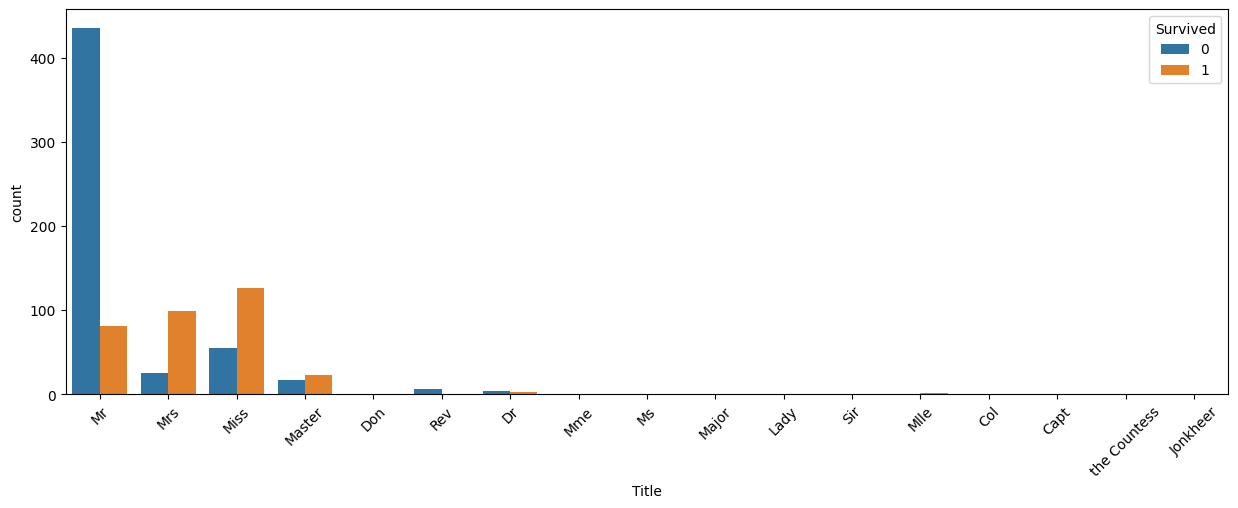

In [8]:
plt.figure(figsize=(15,5))
sns.countplot(data=titanic_df,x='Title',hue='Survived')
plt.xticks(rotation=45)
plt.show()

troche mi sie nie podobaja te randomowe tytuly dziwne wiec polacze je jako rare, ale np mrs. martin dodam jako mrs bo tu cos chyba poszlo nie tak przy tej ekstrakcji wczesniejszej imo

szukalam teraz co znacza te tytuly niektore i mme to madame czyli mrs w sumie; mlle to mademoiselle czyli miss; ms tez miss; mrs. martin to oczywiscie mrs tu niedo konca wiem czemu to jak robilam ekstrakcje wzielo tak duzo tekstu; dr tez zostaje a reszte dodam do rare

In [9]:
titanic_df.loc[titanic_df['Title'].str.startswith('Mrs. Martin', na=False),'Title']='Mrs'
titanic_df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


poprawilam to mrs martin teraz grupuje razem je

In [10]:
titanic_df['Title']=titanic_df['Title'].replace({
    'Ms':'Miss',
    'Mlle':'Miss',
    'Mme':'Mrs',
    'Rev':'Rare',
    'Col':'Rare',
    'Major':'Rare',
    'Countess':'Rare',
    'Capt':'Rare',
    'Jonkheer':'Rare',
    'Don':'Rare',
    'Lady':'Rare',
    'Sir':'Rare',
    'the Countess':'Rare'
})
print(titanic_df['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       16
Dr          7
Name: count, dtype: int64


<Axes: xlabel='Title', ylabel='count'>

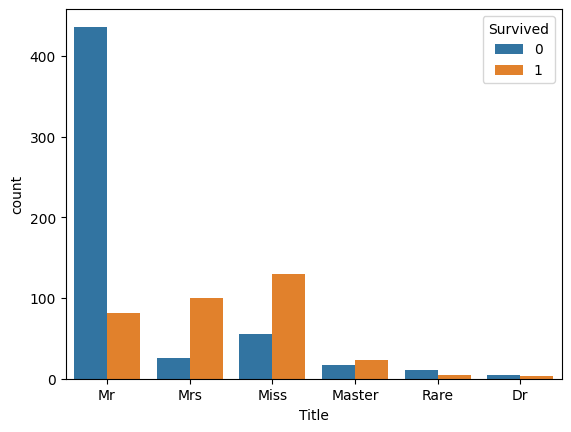

In [11]:
sns.countplot(data=titanic_df,x='Title',hue='Survived')


In [12]:
titanic_df=titanic_df.drop(columns=['Name']) #usuwam znowu name chcialam wczensiej usunac ale cos mi sie psulo i wolalabym skupic sie na dzisiejszym zadaniu niz na tym


In [13]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0
Famsize,0
Alone,0
CabinKnown,0
Title,0
Embarked_C,0


In [14]:
titanic_df=pd.get_dummies(titanic_df,columns=['Title'], dtype=int)

tu zmieniam ten title zeby bylo tak jak mam wyzej embarked zeby te wartosci znow byly zerojedynkowe

In [15]:
titanic_df=titanic_df.drop(columns=['Embarkedcoll']) #tego nie potrzebuje wiec usuwam

X i Y

In [16]:
y=titanic_df['Survived']
x=titanic_df.drop(columns=['Survived'])

tu usuwam survived z tego z czego bedzie przewidywac wlasnie zeby nie bylo data leakage zeby model nie przewidywal survived bazujac na survived

In [17]:
print(x.shape)
print(y.shape)

(891, 16)
(891,)


In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [19]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 16)
(179, 16)
(712,)
(179,)


podzielilam na train i test te dane

teraz dummy classifier

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
dummy = DummyClassifier(strategy='most_frequent') #wybralam most frequent czyli bedzie przewidywac 0
dummy.fit(x_train,y_train)

DummyClassifier(strategy='most_frequent')

In [21]:
y_pred_dummy = dummy.predict(x_test)
accuracy_score(y_test,y_pred_dummy)

0.6145251396648045

predict to przewiduje odpowiedzi i sprawdzam tez accuracy score - okolo 61% poprawnych przewidywan

teraz modele wybieram decision tree i svm

In [22]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=42) #tworze drzewo
tree.fit(x_train,y_train) #ucze model dlatego uzywam train data a nie test data jeszcze

DecisionTreeClassifier(random_state=42)

In [23]:
y_pred_tree_train = tree.predict(x_train) #predykcja na train
y_pred_tree_test = tree.predict(x_test) #a tutaj juz na test

In [24]:
print(y_pred_tree_train[:10]) # tu w obu patrze jak przewidzial pierwsze 10 osob z tych zbiorow
print(y_train.iloc[:10].values)
print(y_pred_tree_test[:10]) #tu te dwa ponizej patrze jakie faktyczne wartosc sa dla 10pierwszych
print(y_test.iloc[:10].values)

[1 0 0 1 1 0 1 0 0 0]
[1 0 0 1 1 0 1 0 1 0]
[0 0 0 0 1 0 1 1 1 0]
[0 0 1 0 1 1 1 0 0 0]


[[92 18]
 [22 47]]


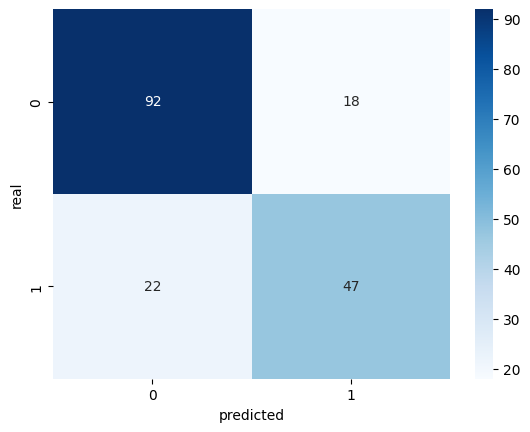

In [25]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix
cm = confusion_matrix(y_test,y_pred_tree_test)
print(cm)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('real')
plt.show()


wiersze to prawdziwa wartosc, a kolumny to przewidziana. 92 osoby to ilosc poprawnie przewidzianych - nie przezyly i model tez przewidzial ze nie przezyly. 18 osob nie przezylo a model przewidzial ze przezyly. 22 osoby przezyly a model zalozyl ze nie. i 47 osob przezylo i model przewidzial ze przezyly

metryki teraz

In [26]:
print("accuracy",accuracy_score(y_test,y_pred_tree_test))
print("recall", recall_score(y_test,y_pred_tree_test))
print("precision",precision_score(y_test,y_pred_tree_test))
print("f1",f1_score(y_test,y_pred_tree_test))

accuracy 0.776536312849162
recall 0.6811594202898551
precision 0.7230769230769231
f1 0.7014925373134329


accuracy dla tego modelu to okolo 78% co jest lepsze od wartosci ktora otrzymalam dla dummy (61%). recall to 68% - to procent osob ktore poprawnie wykryl ze przezyly. dokladnosc to 72% i to oznacza, ze tyle % osob z tych ktore uznal jako zywe faktycznie przezylo.

hiperparametry - max depth i min samples split czyli glebokosc drzewa i to ile minimum info potrzeba zeby dalej mozna bylo podzielic wezel

In [27]:
depths = [2, 3, 4, 5, 6, 8, 10, 12, 14] #tu wybieram glebosc drzewa

In [28]:
results_depths =[]
for depth in depths:
  tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
  tree.fit(x_train,y_train) #tu uuczymy model na train
  y_pred_train = tree.predict(x_train)
  y_pred_test = tree.predict(x_test)
  train_accuracy = accuracy_score(y_train,y_pred_train)
  test_accuracy = accuracy_score(y_test,y_pred_test)
  test_precision = precision_score(y_test,y_pred_test)
  test_recall = recall_score(y_test,y_pred_test)
  print("max depth",depth)
  print("train accuracy",train_accuracy)
  print("test accuracy", test_accuracy)
  print("test precision",test_precision)
  print("test recall",test_recall)
  results_depths.append({
      'max_depth':depth,
      'train_accuracy':train_accuracy,
      'test_accuracy':test_accuracy,
      'test_precision':test_precision,
      'test_recall':test_recall
  })

max depth 2
train accuracy 0.7949438202247191
test accuracy 0.7653631284916201
test precision 0.8461538461538461
test recall 0.4782608695652174
max depth 3
train accuracy 0.8384831460674157
test accuracy 0.8212290502793296
test precision 0.7846153846153846
test recall 0.7391304347826086
max depth 4
train accuracy 0.8497191011235955
test accuracy 0.8324022346368715
test precision 0.8
test recall 0.7536231884057971
max depth 5
train accuracy 0.8707865168539326
test accuracy 0.7932960893854749
test precision 0.7857142857142857
test recall 0.6376811594202898
max depth 6
train accuracy 0.8876404494382022
test accuracy 0.7821229050279329
test precision 0.7678571428571429
test recall 0.6231884057971014
max depth 8
train accuracy 0.9213483146067416
test accuracy 0.8044692737430168
test precision 0.8035714285714286
test recall 0.6521739130434783
max depth 10
train accuracy 0.9438202247191011
test accuracy 0.7877094972067039
test precision 0.7719298245614035
test recall 0.6376811594202898
max de

In [29]:
results_depth_df = pd.DataFrame(results_depths)
results_depth_df

,max_depth,train_accuracy,test_accuracy,test_precision,test_recall
0,2,0.794944,0.765363,0.846154,0.478261
1,3,0.838483,0.821229,0.784615,0.739130
2,4,0.849719,0.832402,0.800000,0.753623
3,5,0.870787,0.793296,0.785714,0.637681
4,6,0.887640,0.782123,0.767857,0.623188
5,8,0.921348,0.804469,0.803571,0.652174
6,10,0.943820,0.787709,0.771930,0.637681
7,12,0.962079,0.787709,0.754098,0.666667
8,14,0.967697,0.782123,0.734375,0.681159


<function matplotlib.pyplot.show(close=None, block=None)>

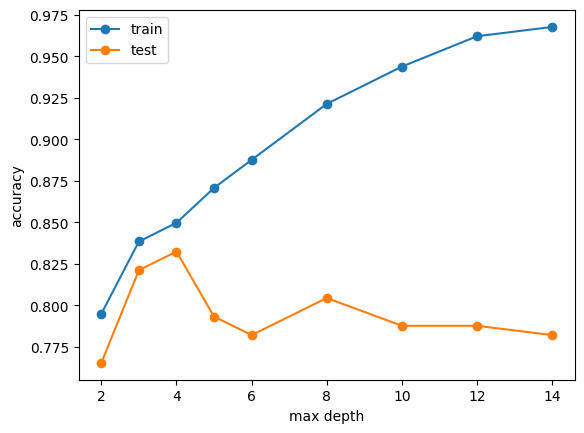

In [30]:
plt.plot(results_depth_df['max_depth'], results_depth_df['train_accuracy'],marker='o',label='train')
plt.plot(results_depth_df['max_depth'], results_depth_df['test_accuracy'],marker='o',label='test')
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.legend()
plt.show

po tym wykresie widac, ze w przypadku train data wraz z gleboksocia poprawia sie accuracy. co niestety jest odwrotne dla test data gdzie ten wykres jest wzrostowo spadkowy(idk czy tak sie mowi w sumie chodzi mi o to ze i rosnie i spada) ale generalnie tendencja jest spadkowa

<function matplotlib.pyplot.show(close=None, block=None)>

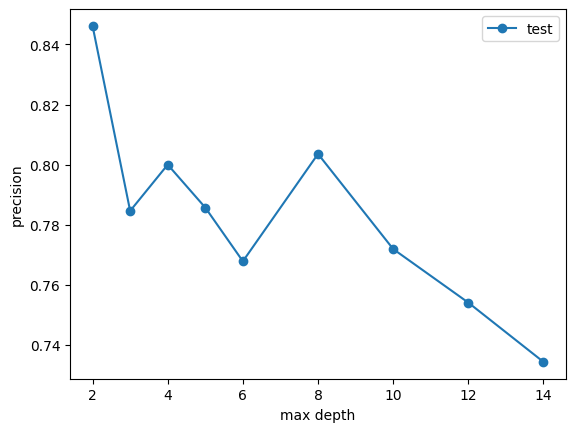

In [31]:
plt.plot(results_depth_df['max_depth'], results_depth_df['test_precision'],marker='o',label='test')
plt.xlabel('max depth')
plt.ylabel('precision')
plt.legend()
plt.show

wraz z glebokoscia drzewa maleje precision

<function matplotlib.pyplot.show(close=None, block=None)>

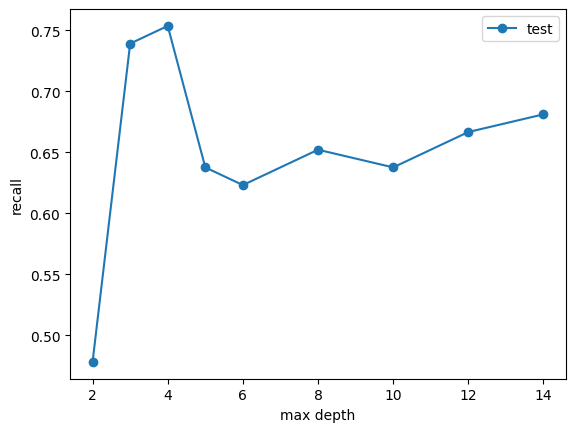

In [32]:
plt.plot(results_depth_df['max_depth'], results_depth_df['test_recall'],marker='o',label='test')
plt.xlabel('max depth')
plt.ylabel('recall')
plt.legend()
plt.show

recall rosnie wraz z glebokoscia bo bardziej zlozone drzewo moze wykryc wiecej osob ktore faktycznie przezyly

teraz min_samples_split

In [33]:
splits = [2, 5, 10, 15, 20, 30, 40]
results_split =[]
for split in splits:
  tree = DecisionTreeClassifier(min_samples_split=split, random_state=42)
  tree.fit(x_train,y_train) #ucze na danych train
  y_pred_train=tree.predict(x_train)#predykcja na train
  y_pred_test=tree.predict(x_test)#a tu na test
  train_accuracy = accuracy_score(y_train,y_pred_train)
  test_accuracy = accuracy_score(y_test,y_pred_test)
  test_precision = precision_score(y_test,y_pred_test)
  test_recall = recall_score(y_test,y_pred_test)
  print("min_samples_split",split)
  print("train accuracy",train_accuracy)
  print("test accuracy", test_accuracy)
  print("test precision",test_precision)
  print("test recall",test_recall)
  results_split.append({'min_samples_split':split,
                        'train_accuracy':train_accuracy,
                        'test_accuracy':test_accuracy,
                        'test_precision':test_precision,
                        'test_recall':test_recall})
  results_split_df = pd.DataFrame(results_split)#zamieniam liste wynikow na dataframe
  results_split_df



min_samples_split 2
train accuracy 0.9831460674157303
test accuracy 0.776536312849162
test precision 0.7230769230769231
test recall 0.6811594202898551
min_samples_split 5
train accuracy 0.9480337078651685
test accuracy 0.7430167597765364
test precision 0.6666666666666666
test recall 0.6666666666666666
min_samples_split 10
train accuracy 0.9241573033707865
test accuracy 0.8044692737430168
test precision 0.7741935483870968
test recall 0.6956521739130435
min_samples_split 15
train accuracy 0.8974719101123596
test accuracy 0.7597765363128491
test precision 0.7096774193548387
test recall 0.6376811594202898
min_samples_split 20
train accuracy 0.8862359550561798
test accuracy 0.7821229050279329
test precision 0.7586206896551724
test recall 0.6376811594202898
min_samples_split 30
train accuracy 0.8834269662921348
test accuracy 0.7821229050279329
test precision 0.7586206896551724
test recall 0.6376811594202898
min_samples_split 40
train accuracy 0.8623595505617978
test accuracy 0.79329608938547

<function matplotlib.pyplot.show(close=None, block=None)>

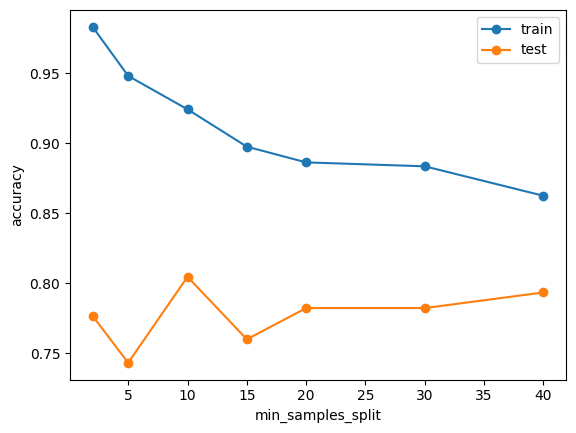

In [34]:
plt.plot(results_split_df['min_samples_split'], results_split_df['train_accuracy'],marker='o',label='train')
plt.plot(results_split_df['min_samples_split'], results_split_df['test_accuracy'],marker='o',label='test')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

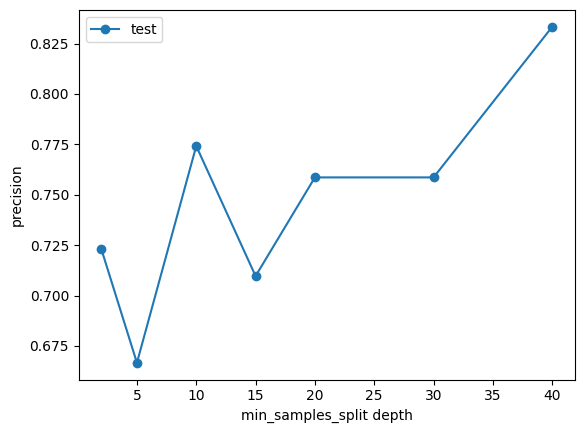

In [35]:
plt.plot(results_split_df['min_samples_split'], results_split_df['test_precision'],marker='o',label='test')
plt.xlabel('min_samples_split depth')
plt.ylabel('precision')
plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

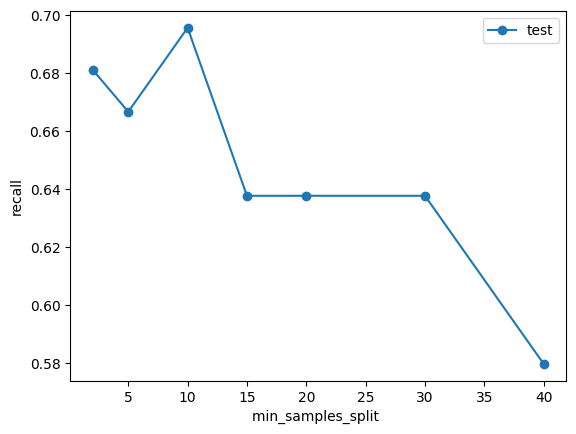

In [36]:
plt.plot(results_split_df['min_samples_split'], results_split_df['test_recall'],marker='o',label='test')
plt.xlabel('min_samples_split ')
plt.ylabel('recall')
plt.legend()
plt.show

In [37]:
results_split_df.loc[results_split_df['test_accuracy'].idxmax()]

,2
min_samples_split,10.000000
train_accuracy,0.924157
test_accuracy,0.804469
test_precision,0.774194
test_recall,0.695652


In [38]:
results_split_df

,min_samples_split,train_accuracy,test_accuracy,test_precision,test_recall
0,2,0.983146,0.776536,0.723077,0.681159
1,5,0.948034,0.743017,0.666667,0.666667
2,10,0.924157,0.804469,0.774194,0.695652
3,15,0.897472,0.759777,0.709677,0.637681
4,20,0.886236,0.782123,0.758621,0.637681
5,30,0.883427,0.782123,0.758621,0.637681
6,40,0.862360,0.793296,0.833333,0.579710


wraz ze wzrostem min samples split drzewo staje sie prostsze wiec accuracy spada - nawyzsze jest dla min samples split 2. jesli chodzi o test accuracy a nie train accuracy to to juz nie idzie prosto w dol wraz z pozdialem - najwiekszy procentowo wynik jest dla min samples split 10 i jest to 80% co poprawia model bo wczesniej wartosc ta byla ponizej 80%. porownujac min samples split 2 i 10 widzimy ze train accuracy spada, percision rosnie czyli jest mniej false positives, test accuracy rosnie czyli model lepiej generalizuje

teraz drugi model ps mam nadzieje ze pisze logiczne skladniowo zdania bo moja podroz pociagiem ktora jest powodem tego czemu to zadanie jest spoznione (sorki) wyciagnela ze mnie wszystko i umieram z herbata w domu wlasnie

svm

In [39]:
from sklearn.svm import SVC

In [40]:
svm = SVC() #tu tworze model svm z domyslnymi parametrami juz mam podzielone dane na train i test wiec nie robie tego znow
svm.fit(x_train,y_train) #ucze model na train
y_pred_train_svm = svm.predict(x_train) #przewiduje model klase dla innych danych treningowych
y_pred_test_svm = svm.predict(x_test) #a tutaj dla danych testowych

In [41]:
print("train accuracy",accuracy_score(y_train,y_pred_train_svm))
print("test accuracy",accuracy_score(y_test,y_pred_test_svm))
print("test precision",precision_score(y_test,y_pred_test_svm))
print("test recall",recall_score(y_test,y_pred_test_svm))


train accuracy 0.7008426966292135
test accuracy 0.6201117318435754
test precision 0.5161290322580645
test recall 0.2318840579710145


In [42]:
cm = confusion_matrix(y_test,y_pred_test)
print(cm)

[[102   8]
 [ 29  40]]


po powyzszych wynikach widac ze model poprawnie oznacza 62% osob w zbiorze. to minimalnie lepiej niz dummy. precision to okolo 56% czyli tyle procent ktore przewidzial ze przezylo faktycznie przezylo. recall to 23% co oznacza, ze ze wszystkich osob ktore prezzyly model wykryl niecale 30%. accuracy jest lepsze dla danych train niz testowych.

wybralam hiperparametr c - kiedy jest maly to model bardziej toleruje bledy, a wiekszy to bardziej stara sie zrobic poprawna klasyfikacje ale z tego co sie dowiedzialam to jest wieksza szansa na overfitting. oprocz tego tez gamma - jesli jest mala to wplyw obserwacji jest rozlegly a duza to jest granica bardizej zlozona. bo gamma okresla jak duzy wplyw na granice decyzyjna ma jedna obserwacja

In [45]:
c_values=[0.01,0.1,1,10,100] #wartosci c do sprawdzenia
results=[]
for c in c_values:
  svm=SVC(C=c, kernel='rbf',gamma=1,random_state=42) # tu tworze model, c to testowana wartosc, kernel rfb tzn ze uzywamy jadra rbf, a gamma na ten moment jst stala
  svm.fit(x_train,y_train) #uczymy model
  y_pred_train_svm = svm.predict(x_train) #no i predykcja teraz
  y_pred_test_svm = svm.predict(x_test)
  train_accuracy = accuracy_score(y_train,y_pred_train_svm)
  test_accuracy = accuracy_score(y_test,y_pred_test_svm)
  test_precision = precision_score(y_test,y_pred_test_svm)
  test_recall = recall_score(y_test,y_pred_test_svm)
  print("c",c)
  print("train accuracy",train_accuracy)
  print("test accuracy",test_accuracy)
  print("test precision",test_precision)
  print("test recall",test_recall)
  results.append({'C':c,'train_accuracy':train_accuracy,'test_precision':test_precision,'test_recall':test_recall,'test_accuracy':test_accuracy})
results_c_df = pd.DataFrame(results)
results_c_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


c 0.01
train accuracy 0.6165730337078652
test accuracy 0.6145251396648045
test precision 0.0
test recall 0.0
c 0.1
train accuracy 0.6306179775280899
test accuracy 0.6256983240223464
test precision 0.75
test recall 0.043478260869565216
c 1
train accuracy 0.9705056179775281
test accuracy 0.6312849162011173
test precision 0.5882352941176471
test recall 0.14492753623188406
c 10
train accuracy 0.976123595505618
test accuracy 0.6480446927374302
test precision 0.6363636363636364
test recall 0.2028985507246377
c 100
train accuracy 0.9775280898876404
test accuracy 0.6480446927374302
test precision 0.6363636363636364
test recall 0.2028985507246377


,C,train_accuracy,test_precision,test_recall,test_accuracy
0,0.01,0.616573,0.000000,0.000000,0.614525
1,0.10,0.630618,0.750000,0.043478,0.625698
2,1.00,0.970506,0.588235,0.144928,0.631285
3,10.00,0.976124,0.636364,0.202899,0.648045
4,100.00,0.977528,0.636364,0.202899,0.648045


wraz ze wzrostem wartosci c train accuracy rosnie - od poczatkowej wartosci 61% do prawe 98%. wieksze c pozwala modelowi coraz lepiej dopasowac sie do danych treningowych. tes accuracy tez rosnie ale zdecydowanie wolniej niz train accuracy bo tylko o 4 procent. c=100 jest takie same jak c=10 wiec przez brak poprawy bez sensu wybierac wieksze c.
recall tez sie poprawia - wartosc ta nawet przy c=100 jest niska ale zdecydowania widac poprawe w stotunku do 0,01. jest duza roznica dla c=10 jesli chdozi o train accuracy a test - ponad 30% model mega dobrze sie dopasowal do danych treningowych ale gorzej dla nowych dancyh testowych. w sprawdzaniu hiperparametru gamma uzyje c=10

In [47]:
gamma_values=[0.001,0.01,0.1,1,10]
results_gamma=[]
for gamma in gamma_values:
  svm=SVC(C=10, gamma=gamma, kernel='rbf')
  svm.fit(x_train,y_train)
  y_pred_train_svm = svm.predict(x_train)
  y_pred_test_svm = svm.predict(x_test)
  train_accuracy = accuracy_score(y_train,y_pred_train_svm)
  test_accuracy = accuracy_score(y_test,y_pred_test)
  test_precision = precision_score(y_test,y_pred_test_svm)
  test_recall = recall_score(y_test,y_pred_test_svm)
  print("gamma",gamma)
  print("train accuracy",train_accuracy)
  print("test accuracy",test_accuracy)
  print("test precision",test_precision)
  print("test recall",test_recall)
  results_gamma.append({'gamma':gamma,'train_accuracy':train_accuracy,'test_precision':test_precision,'test_recall':test_recall,'test_accuracy':test_accuracy})
results_gamma_df = pd.DataFrame(results_gamma)
results_gamma_df


gamma 0.001
train accuracy 0.8160112359550562
test accuracy 0.7932960893854749
test precision 0.6911764705882353
test recall 0.6811594202898551
gamma 0.01
train accuracy 0.8806179775280899
test accuracy 0.7932960893854749
test precision 0.7101449275362319
test recall 0.7101449275362319
gamma 0.1
train accuracy 0.9550561797752809
test accuracy 0.7932960893854749
test precision 0.671875
test recall 0.6231884057971014
gamma 1
train accuracy 0.976123595505618
test accuracy 0.7932960893854749
test precision 0.6363636363636364
test recall 0.2028985507246377
gamma 10
train accuracy 0.9789325842696629
test accuracy 0.7932960893854749
test precision 0.6363636363636364
test recall 0.10144927536231885


,gamma,train_accuracy,test_precision,test_recall,test_accuracy
0,0.001,0.816011,0.691176,0.681159,0.793296
1,0.010,0.880618,0.710145,0.710145,0.793296
2,0.100,0.955056,0.671875,0.623188,0.793296
3,1.000,0.976124,0.636364,0.202899,0.793296
4,10.000,0.978933,0.636364,0.101449,0.793296


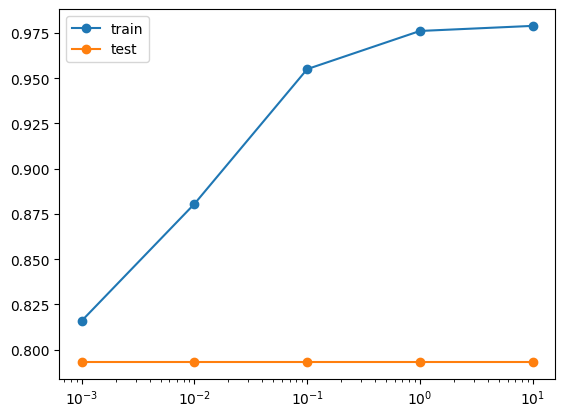

In [51]:
plt.plot(results_gamma_df['gamma'], results_gamma_df['train_accuracy'],marker='o',label='train')
plt.plot(results_gamma_df['gamma'], results_gamma_df['test_accuracy'],marker='o',label='test')
plt.xscale('log') #skala log bo testuje wartosci 10 razy wieksze niz poprzednia przy gammie 0.01,0.1 itp i wykres wtedy ladniej wychodzi imo
plt.legend()
plt.show()

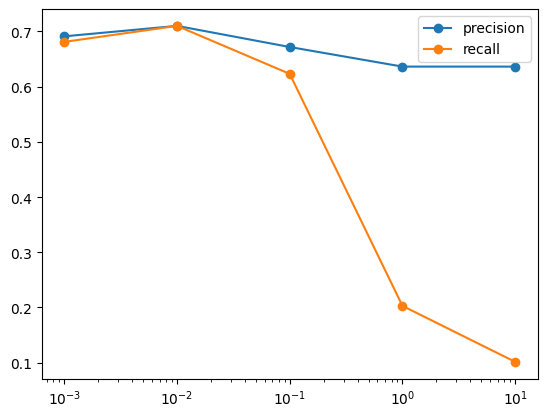

In [53]:
plt.plot(results_gamma_df['gamma'],results_gamma_df['test_precision'],marker='o',label='precision')
plt.plot(results_gamma_df['gamma'],results_gamma_df['test_recall'],marker='o',label='recall')
plt.xscale('log')
plt.legend()
plt.show()

In [55]:
results_gamma_df.loc[results_gamma_df['test_accuracy'].idxmax()]

,0
gamma,0.001000
train_accuracy,0.816011
test_precision,0.691176
test_recall,0.681159
test_accuracy,0.793296


test accuracy bylo takie samo dla gammy 0.01 i 0.001 wzial idxmax po prostu pierwsza wartosc sprawdzam teraz dla innego parametru

In [56]:
results_gamma_df.loc[results_gamma_df['test_precision'].idxmax()]

,1
gamma,0.010000
train_accuracy,0.880618
test_precision,0.710145
test_recall,0.710145
test_accuracy,0.793296


no i tu juz widac ze 0.01 jest lepsze test precision jest wiekszetest recall tez. teraz robimy finalny svm

In [59]:
final_svm=SVC(C=10, gamma=0.01, kernel='rbf')
final_svm.fit(x_train,y_train)
y_pred_train_svm = final_svm.predict(x_train)
y_pred_test_svm = final_svm.predict(x_test)
train_accuracy = accuracy_score(y_train,y_pred_train_svm)
test_accuracy = accuracy_score(y_test,y_pred_test_svm)
print("train accuracy",train_accuracy)
print("test accuracy",test_accuracy)
print("test precision",precision_score(y_test,y_pred_test_svm))
print("test recall",recall_score(y_test,y_pred_test_svm))
cm = confusion_matrix(y_test,y_pred_test_svm)
print(cm)

train accuracy 0.8806179775280899
test accuracy 0.776536312849162
test precision 0.7101449275362319
test recall 0.7101449275362319
[[90 20]
 [20 49]]


na danych testowych accuracy jest wiedze o 11 procent.precision wynosi 71% oznacza to ze 715 dobrze przewidzial czy przezyly czy nie
duza poprawa jest jesli chodzi o recall bo wynosi on 71 procent tez a bez hiperparametrow wynosil okolo 20 wiec tu na plus.

teraz porownam tabelke po tych hiperrparametrach dla obu mofeli

In [60]:
compare = pd.DataFrame({
    'model':['Decision tree','SVM'],
    'train_accuracy':[
        accuracy_score(y_train,y_pred_tree_train),
        accuracy_score(y_train,y_pred_train_svm)
    ],
    'test_accuracy':[
        accuracy_score(y_test,y_pred_tree_test),
        accuracy_score(y_test,y_pred_test_svm)
    ],
    'test_precision':[
        precision_score(y_test,y_pred_tree_test),
        precision_score(y_test,y_pred_test_svm)
    ],
    'test_recall':[
        recall_score(y_test,y_pred_tree_test),
        recall_score(y_test,y_pred_test_svm)
    ]
    })
compare

,model,train_accuracy,test_accuracy,test_precision,test_recall
0,Decision tree,0.983146,0.776536,0.723077,0.681159
1,SVM,0.880618,0.776536,0.710145,0.710145


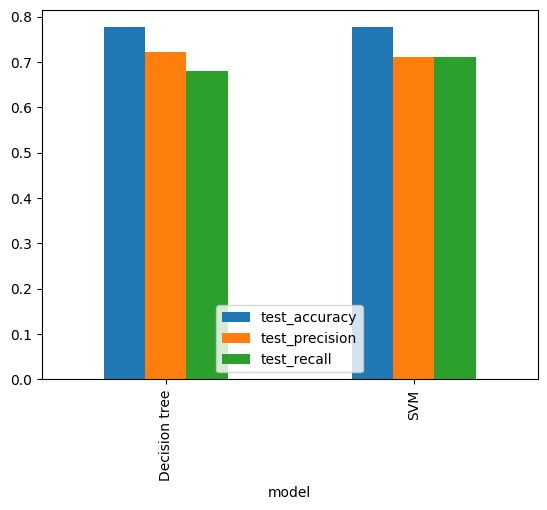

In [61]:
compare_plot = compare.set_index('model')
compare_plot[['test_accuracy','test_precision','test_recall']].plot(kind='bar')
plt.legend()
plt.show()

jak porownuje modele to widac ze test accuracy jest w sumie takie samo. ale decision tree ma wieksze precision a svm wiekszy recall. oznacza to ze svm lepiej wykrywa osoby ktore przezyly a decision tree ma mniej false positives. decision tree ma wysokie train accuracy ale testowe jest mniejsze o 20%. svm ma mniejsza roznice miedzy tymi wartosciami co sugeruje lepsze generalizowanie danych.
w sumie i jeden i drugi model maja podbne wynik, w porownaniu do dummy clasifier oba modele sa lepsze wiec super.